First, I used Google Colab’s file upload tool to open a file picker and upload a the ADA Bus Stop dataset from my computer into the notebook environment.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ADA_Bus_Stop.csv to ADA_Bus_Stop.csv


In [ ]:
import pandas as pd
df_bus = pd.read_csv('ADA_Bus_Stop.csv')

I cleaned up the CONDITION column in my bus stop dataset by removing extra spaces and standardizing everything to uppercase so the categories are consistent. Then I counted how many times each condition appears, and calculated the total number of records so I can use it later for percentages in my analysis.

In [ ]:
df_bus['CONDITION'] = df_bus['CONDITION'].str.strip().str.upper()

condition_counts = df_bus['CONDITION'].value_counts()

total = condition_counts.sum()

Next, I created a bar chart to visualize the condition of bus stops from my data. I colored the bars so that non-compliant conditions show up in red and compliant shows up in blue, making it easier to visually separate the two groups. I also calculated the percentages of each category and added them to a custom legend the legend. From the results, I can see that about two-thirds of the bus stops appear to be compliant, which suggests that most of the system is generally up to ADA standards, although there is still a noticeable portion that is not.

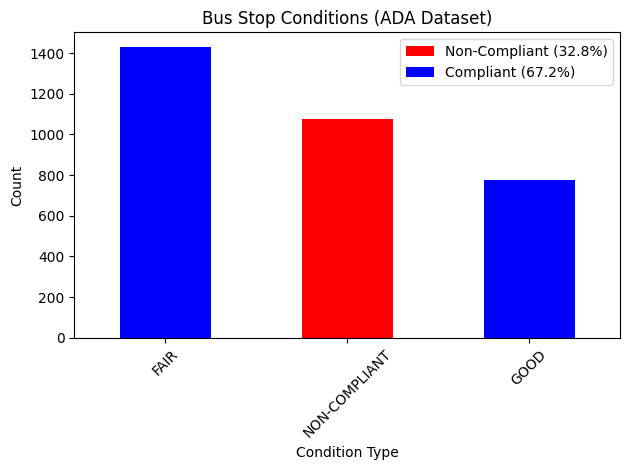

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

colors = [ 'red' if 'NON' in cond else 'blue'
    for cond in condition_counts.index]

plt.figure()
condition_counts.plot(kind='bar', color=colors)

plt.title('Bus Stop Conditions (ADA Dataset)')
plt.xlabel('Condition Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

non_compliant = condition_counts[condition_counts.index.str.contains('NON')].sum()
compliant = total - non_compliant

non_pct = (non_compliant / total) * 100
comp_pct = (compliant / total) * 100

legend_elements = [
    Patch(facecolor='red', label=f'Non-Compliant ({non_pct:.1f}%)'),
    Patch(facecolor='blue', label=f'Compliant ({comp_pct:.1f}%)')
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

Like before I implemented Google Colab’s file upload tool to open a file picker and upload a the ADA Audible Pedstrian dataset.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ADA_Audible_Pedestrian_Signals.csv to ADA_Audible_Pedestrian_Signals.csv


In [ ]:
import pandas as pd
df_signal = pd.read_csv('ADA_Audible_Pedestrian_Signals.csv')

I cleaned the PUSHBUTTON_TYPE column in my signal dataset by filling in missing values with “NONE” since python was ready the NONE columns as empty Nas, so they wouldn’t be lost in the analysis. Then I removed extra spaces and standardized everything to uppercase so all entries are consistent and easier to group. After that, I counted how many times each pushbutton type appears and sorted the results so the data is ordered from smallest to largest

In [ ]:
df_signal['PUSHBUTTON_TYPE'] = df_signal['PUSHBUTTON_TYPE'].fillna('NONE')
df_signal['PUSHBUTTON_TYPE'] = df_signal['PUSHBUTTON_TYPE'].str.strip().str.upper()

push_counts = df_signal['PUSHBUTTON_TYPE'].value_counts().sort_values()

After that, I built a horizontal bar chart where I color-coded the categories based on ADA compliance: missing values are green, the Type C compliant pushbuttons are blue, and all other types are red to represent non-compliance. I also wrapped long labels so they don’t stretch the chart. Finally, I calculated the percentage of compliant, non-compliant, and missing values and added them to a legend so the graph shows both raw counts and overall proportions.

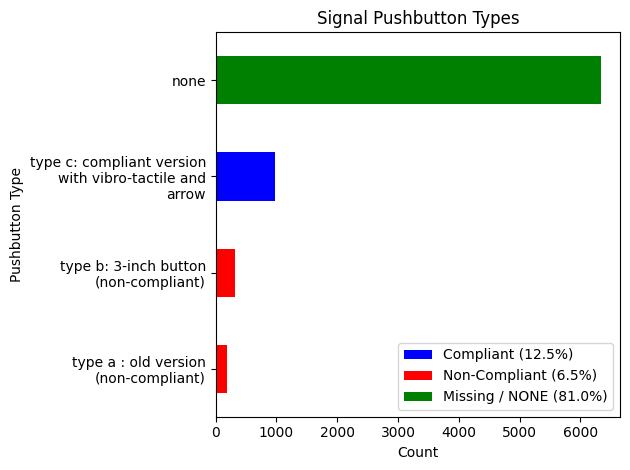

In [ ]:
import matplotlib.pyplot as plt
import textwrap
from matplotlib.patches import Patch

df_signal['PUSHBUTTON_TYPE'] = (
    df_signal['PUSHBUTTON_TYPE']
    .fillna('NONE')
    .astype(str)
    .str.lower()
    .str.strip()
)

push_counts = df_signal['PUSHBUTTON_TYPE'].value_counts().sort_values(ascending=True)

total = push_counts.sum()

colors = [
    "green" if label == "none"
    else "blue" if ("type c" in label and "vibro-tactile" in label)
    else "red"
    for label in push_counts.index
]

fig, ax = plt.subplots()
push_counts.plot(kind='barh', color=colors, ax=ax)

ax.set_yticklabels([
    "\n".join(textwrap.wrap(label, 25))
    for label in push_counts.index
])

ax.set_title('Signal Pushbutton Types')
ax.set_xlabel('Count')
ax.set_ylabel('Pushbutton Type')

missing = push_counts.get("none", 0)

compliant = sum(
    v for k, v in push_counts.items()
    if ("type c" in k and "vibro-tactile" in k)
)

non_compliant = total - missing - compliant

missing_pct = (missing / total) * 100
compliant_pct = (compliant / total) * 100
non_pct = (non_compliant / total) * 100

ax.legend(handles=[
    Patch(facecolor='blue', label=f'Compliant ({compliant_pct:.1f}%)'),
    Patch(facecolor='red', label=f'Non-Compliant ({non_pct:.1f}%)'),
    Patch(facecolor='green', label=f'Missing / NONE ({missing_pct:.1f}%)')
])

plt.tight_layout()
plt.show()